In [1]:
from pathlib import Path

import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
from skimage.color import rgb2lab
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_holes, remove_small_objects
from sklearn.cluster import KMeans

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 11})

SCIEZKA_ZDJECIA = Path("data/tapias_ortofoto.tif")   
KATALOG_WYNIKOW = Path("results")
KATALOG_WYNIKOW.mkdir(exist_ok=True)

FRAGMENT = np.s_[850:1250, 1000:1400]

Rozmiar:          1731 x 1731 px
Układ (CRS):      EPSG:32618
GSD:              0.120 m/piksel  (1 piksel = 144 cm²)
Zasięg zdjęcia:   208 x 208 m
Piksele ważne:    92.4%  (reszta to tło poza ortomozaikiem)


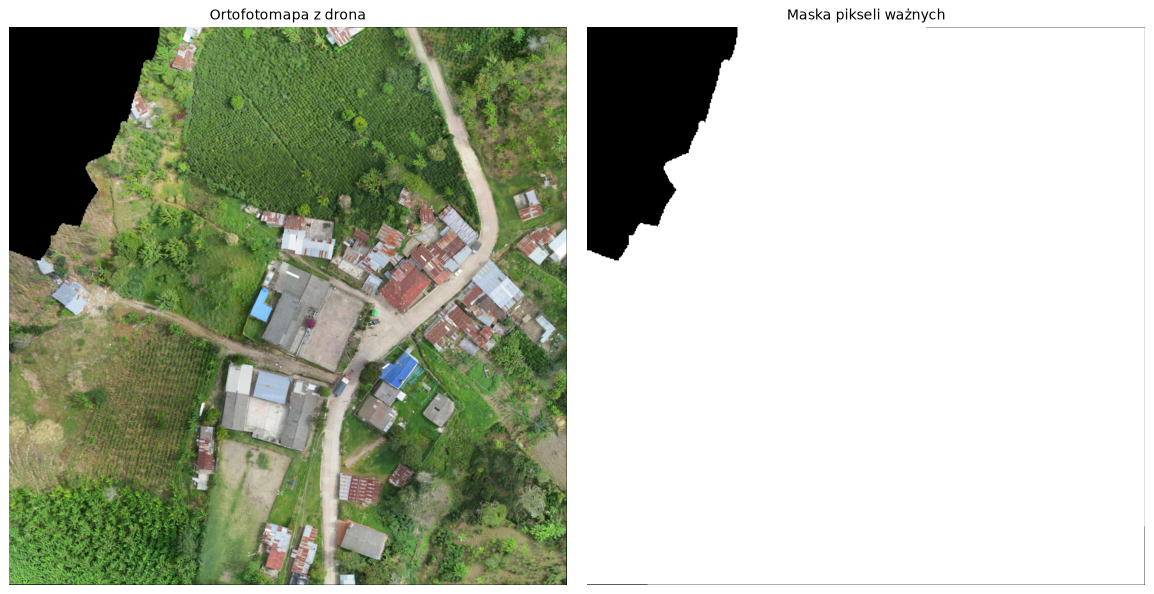

In [2]:
def wczytaj_zdjecie(sciezka, gsd_reczne=None):
    """Zwraca: rgb (H,W,3 uint8), waznie (H,W bool), profil (transform, crs), gsd [m/piksel]."""
    with rasterio.open(sciezka) as src:
        if src.count < 3 or src.dtypes[0] != "uint8":
            raise ValueError(f"Oczekuję 8-bitowego RGB, a jest: {src.count} pasm, {src.dtypes[0]}")
        rgb = np.moveaxis(src.read([1, 2, 3]), 0, -1)
        profil = {"transform": src.transform, "crs": src.crs}
        metryczny = src.crs is not None and src.crs.is_projected
        gsd = src.res[0] if metryczny else gsd_reczne
    waznie = ~(rgb == 0).all(axis=-1)          # czarne tło ortomozaiku = brak danych
    if gsd is None:
        raise ValueError("Zdjęcie nie jest w układzie metrycznym — podaj gsd_reczne (m/piksel).")
    return rgb, waznie, profil, gsd


rgb, waznie, profil, gsd = wczytaj_zdjecie(SCIEZKA_ZDJECIA)

print(f"Rozmiar:          {rgb.shape[1]} x {rgb.shape[0]} px")
print(f"Układ (CRS):      {profil['crs']}")
print(f"GSD:              {gsd:.3f} m/piksel  (1 piksel = {gsd**2 * 1e4:.0f} cm²)")
print(f"Zasięg zdjęcia:   {rgb.shape[1] * gsd:.0f} x {rgb.shape[0] * gsd:.0f} m")
print(f"Piksele ważne:    {waznie.mean():.1%}  (reszta to tło poza ortomozaikiem)")

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5))
ax[0].imshow(rgb); ax[0].set_title("Ortofotomapa z drona")
ax[1].imshow(waznie, cmap="gray"); ax[1].set_title("Maska pikseli ważnych")
for a in ax: a.axis("off")
plt.tight_layout()

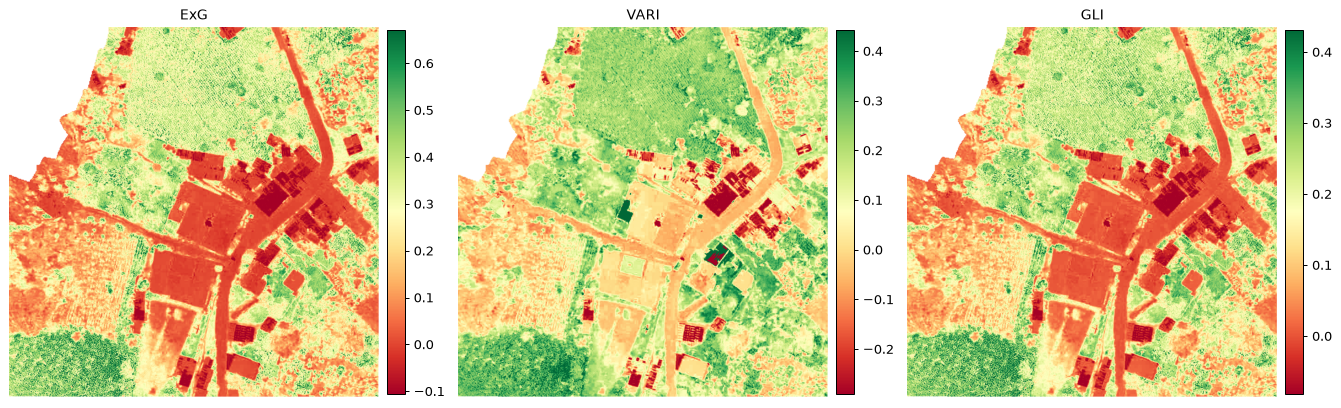

In [3]:
def indeksy_rgb(rgb):
    """Zwraca słownik {nazwa: mapa indeksu float32} dla obrazu RGB uint8."""
    R, G, B = (rgb[..., i].astype(np.float32) for i in range(3))
    eps = 1e-6
    suma = R + G + B + eps
    r, g, b = R / suma, G / suma, B / suma                   # współrzędne chromatyczne
    exg = 2 * g - r - b
    vari = np.clip((G - R) / (G + R - B + eps), -1, 1)       # clip: mianownik bywa ~0
    gli = (2 * G - R - B) / (2 * G + R + B + eps)
    return {"ExG": exg, "VARI": vari, "GLI": gli}


indeksy = indeksy_rgb(rgb)

fig, ax = plt.subplots(1, 3, figsize=(15, 5.2))
for a, (nazwa, mapa) in zip(ax, indeksy.items()):
    obraz = np.ma.masked_where(~waznie, mapa)                # tło nie liczy się do skali kolorów
    im = a.imshow(obraz, cmap="RdYlGn", vmin=np.percentile(mapa[waznie], 1), vmax=np.percentile(mapa[waznie], 99))
    a.set_title(nazwa); a.axis("off")
    plt.colorbar(im, ax=a, fraction=0.046, pad=0.02)
plt.tight_layout()

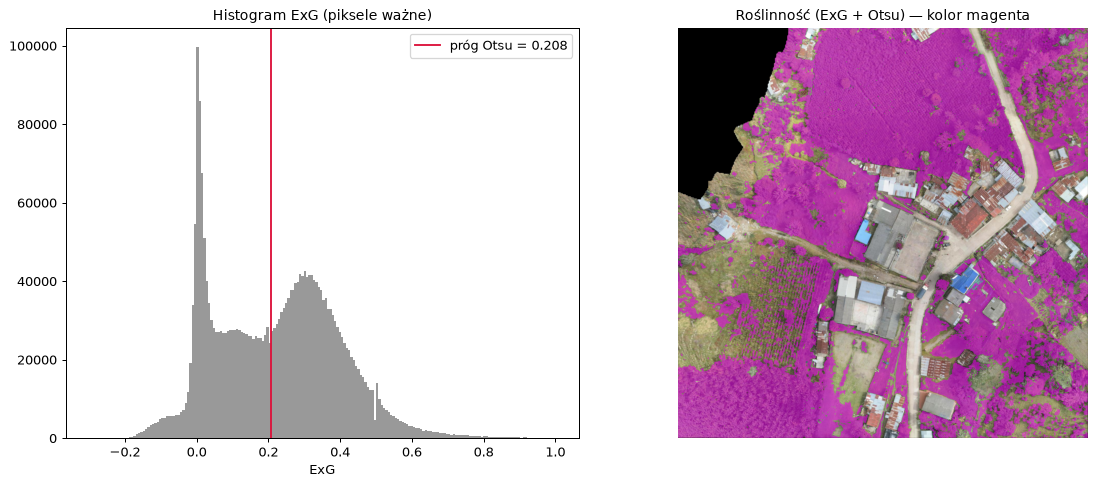

In [4]:
def maska_progowa(mapa_indeksu, waznie):
    prog = threshold_otsu(mapa_indeksu[waznie])
    return (mapa_indeksu > prog) & waznie, prog


def nakladka(rgb, maska, kolor=(255, 0, 255), alfa=0.55):
    """Półprzezroczysta maska nałożona na zdjęcie (do oceny wzrokowej)."""
    wynik = rgb.astype(np.float32)
    wynik[maska] = (1 - alfa) * wynik[maska] + alfa * np.array(kolor, dtype=np.float32)
    return wynik.astype(np.uint8)


maska_exg, prog_exg = maska_progowa(indeksy["ExG"], waznie)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.4]})
ax[0].hist(indeksy["ExG"][waznie], bins=200, range=(-0.3, 1.0), color="0.6")
ax[0].axvline(prog_exg, color="crimson", label=f"próg Otsu = {prog_exg:.3f}")
ax[0].set_title("Histogram ExG (piksele ważne)"); ax[0].set_xlabel("ExG"); ax[0].legend()
ax[1].imshow(nakladka(rgb, maska_exg)); ax[1].axis("off")
ax[1].set_title("Roślinność (ExG + Otsu) — kolor magenta")
plt.tight_layout()

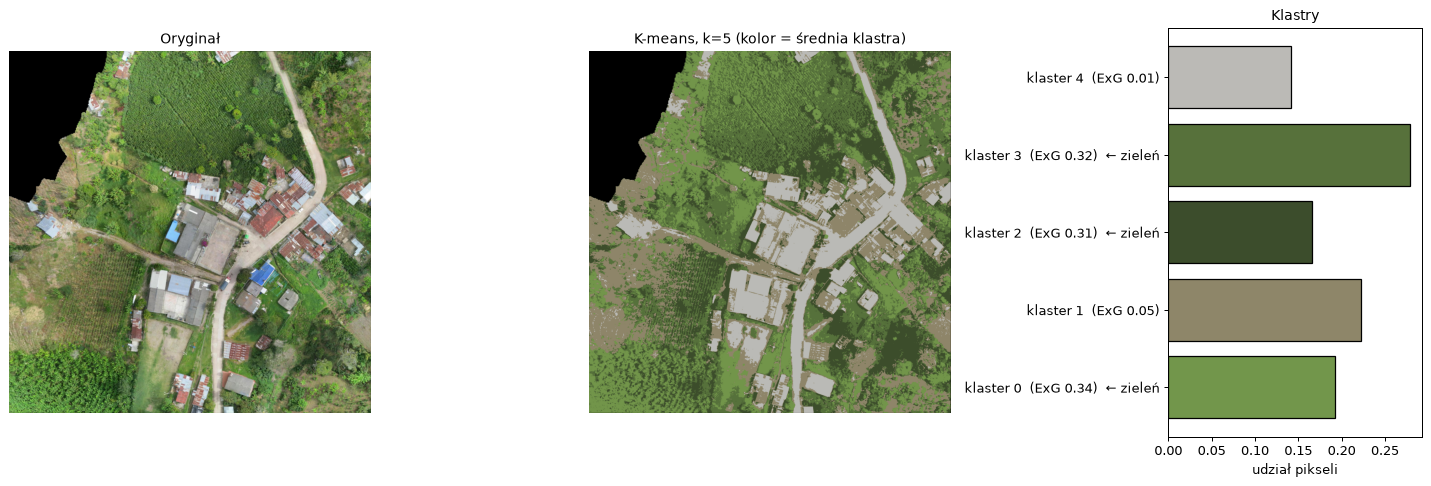

In [7]:
K = 5
PROG_EXG_KLASTRA = 0.10   # klaster uznajemy za zieleń, gdy jego średni ExG jest wyższy


def klasteryzacja_kmeans(rgb, waznie, k=K, wielkosc_probki=50_000, seed=0):
    """Zwraca etykiety (H,W; -1 = piksel nieważny) oraz średni kolor RGB każdego klastra."""
    piksele = rgb2lab(rgb)[waznie]
    probka = np.random.default_rng(seed).choice(len(piksele), min(wielkosc_probki, len(piksele)), replace=False)
    km = KMeans(n_clusters=k, n_init=5, random_state=seed).fit(piksele[probka])
    etykiety = np.full(waznie.shape, -1, dtype=np.int16)
    etykiety[waznie] = km.predict(piksele)
    kolory = np.array([rgb[etykiety == i].mean(axis=0) for i in range(k)])
    return etykiety, kolory


etykiety, kolory_klastrow = klasteryzacja_kmeans(rgb, waznie)

# klastry roślinności = te o wysokim średnim ExG (albo wpisz ręcznie po obejrzeniu wykresu, np. [0, 2, 3])
srednie_exg = np.array([indeksy["ExG"][etykiety == i].mean() for i in range(K)])
klastry_roslinne = [i for i in range(K) if srednie_exg[i] > PROG_EXG_KLASTRA]
maska_kmeans = np.isin(etykiety, klastry_roslinne)

# obraz „skwantowany": każdy piksel pokolorowany średnim kolorem swojego klastra
skwantyzowany = np.zeros_like(rgb)
for i in range(K):
    skwantyzowany[etykiety == i] = kolory_klastrow[i].astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1, 0.7]})
ax[0].imshow(rgb); ax[0].set_title("Oryginał")
ax[1].imshow(skwantyzowany); ax[1].set_title(f"K-means, k={K} (kolor = średnia klastra)")
for a in ax[:2]: a.axis("off")
udzial = [(etykiety == i).sum() / waznie.sum() for i in range(K)]
ax[2].barh(range(K), udzial, color=kolory_klastrow / 255, edgecolor="k")
ax[2].set_yticks(range(K), [f"klaster {i}  (ExG {srednie_exg[i]:.2f})" + ("  ← zieleń" if i in klastry_roslinne else "") for i in range(K)])
ax[2].set_xlabel("udział pikseli"); ax[2].set_title("Klastry")
plt.tight_layout()

IoU (ExG+Otsu vs k-means): 0.832


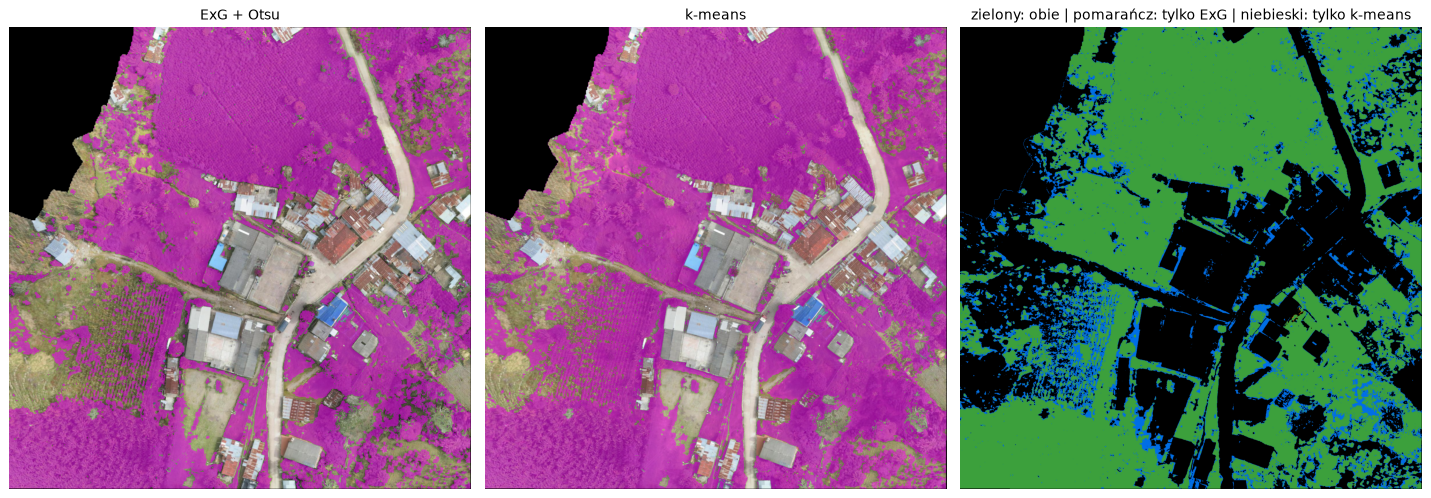

In [8]:
def iou(a, b):
    return (a & b).sum() / (a | b).sum()


print(f"IoU (ExG+Otsu vs k-means): {iou(maska_exg, maska_kmeans):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 5.5))
ax[0].imshow(nakladka(rgb, maska_exg)); ax[0].set_title("ExG + Otsu")
ax[1].imshow(nakladka(rgb, maska_kmeans)); ax[1].set_title("k-means")
roznica = np.zeros((*waznie.shape, 3), dtype=np.uint8)
roznica[maska_exg & maska_kmeans] = (60, 160, 60)      # obie metody: roślinność
roznica[maska_exg & ~maska_kmeans] = (230, 120, 0)     # tylko ExG
roznica[~maska_exg & maska_kmeans] = (0, 110, 230)     # tylko k-means
ax[2].imshow(roznica); ax[2].set_title("zielony: obie | pomarańcz: tylko ExG | niebieski: tylko k-means")
for a in ax: a.axis("off")
plt.tight_layout()

Piksele roślinności: przed 1,467,049 -> po 1,455,585
Liczba oddzielnych plam: przed 1,290 -> po 185


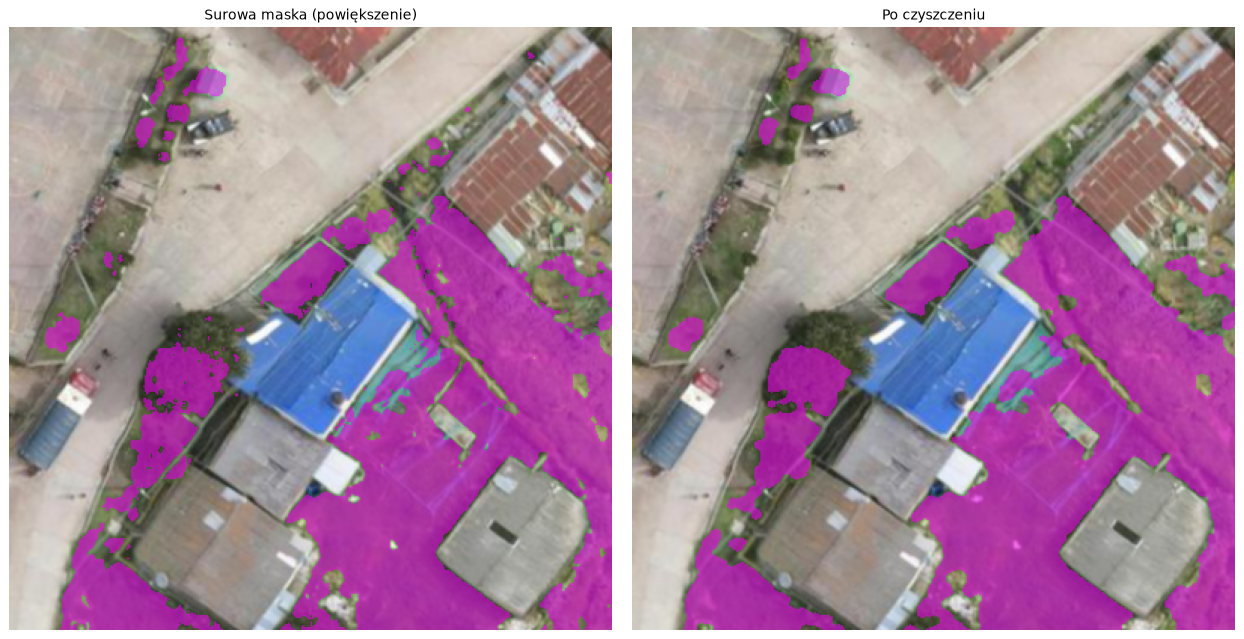

In [9]:
def oczysc_maske(maska, waznie, gsd, promien_m=0.25, min_obiekt_m2=1.0, min_dziura_m2=1.0):
    piksel_m2 = gsd ** 2
    r = max(1, round(promien_m / gsd))
    jadro = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
    m = maska.astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, jadro)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, jadro)
    m = m.astype(bool) & waznie                              # zamknięcie nie może „wyjść" na tło
    m = remove_small_objects(m, max_size=int(min_obiekt_m2 / piksel_m2))
    m = remove_small_holes(m, max_size=int(min_dziura_m2 / piksel_m2))
    return m


maska_czysta = oczysc_maske(maska_exg, waznie, gsd)

print(f"Piksele roślinności: przed {maska_exg.sum():,} -> po {maska_czysta.sum():,}")
print(f"Liczba oddzielnych plam: przed {cv2.connectedComponents(maska_exg.astype(np.uint8))[0] - 1:,} "
      f"-> po {cv2.connectedComponents(maska_czysta.astype(np.uint8))[0] - 1:,}")

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(nakladka(rgb, maska_exg)[FRAGMENT]); ax[0].set_title("Surowa maska (powiększenie)")
ax[1].imshow(nakladka(rgb, maska_czysta)[FRAGMENT]); ax[1].set_title("Po czyszczeniu")
for a in ax: a.axis("off")
plt.tight_layout()

In [10]:
def statystyki(maska, waznie, gsd):
    piksel_m2 = gsd ** 2
    razem, rosl = waznie.sum() * piksel_m2, maska.sum() * piksel_m2
    return {"powierzchnia_zdjecia_ha": razem / 1e4, "roslinnosc_ha": rosl / 1e4,
            "roslinnosc_proc": 100 * rosl / razem}


pd.DataFrame({
    "ExG + Otsu (surowa)": statystyki(maska_exg, waznie, gsd),
    "ExG + Otsu (po czyszczeniu)": statystyki(maska_czysta, waznie, gsd),
    "k-means": statystyki(maska_kmeans, waznie, gsd),
}).round(2)

,ExG + Otsu (surowa),ExG + Otsu (po czyszczeniu),k-means
powierzchnia_zdjecia_ha,3.99,3.99,3.99
roslinnosc_ha,2.11,2.10,2.54
roslinnosc_proc,52.99,52.57,63.69


In [11]:
def zapisz_maske_geotiff(sciezka, maska, waznie, profil):
    dane = np.where(waznie, maska, 255).astype(np.uint8)
    with rasterio.open(
        sciezka, "w", driver="GTiff", height=dane.shape[0], width=dane.shape[1], count=1,
        dtype="uint8", crs=profil["crs"], transform=profil["transform"], nodata=255, compress="lzw",
    ) as dst:
        dst.write(dane, 1)


def maska_do_poligonow(maska, profil, gsd):
    geometrie = [shape(g) for g, _ in shapes(maska.astype(np.uint8), mask=maska, transform=profil["transform"])]
    gdf = gpd.GeoDataFrame(geometry=geometrie, crs=profil["crs"])
    gdf["geometry"] = gdf.geometry.simplify(gsd)
    gdf["pow_m2"] = gdf.geometry.area.round(2)                # układ metryczny -> m²
    return gdf


zapisz_maske_geotiff(KATALOG_WYNIKOW / "roslinnosc_maska.tif", maska_czysta, waznie, profil)
poligony = maska_do_poligonow(maska_czysta, profil, gsd)
poligony.to_file(KATALOG_WYNIKOW / "roslinnosc.gpkg", driver="GPKG")
plt.imsave(KATALOG_WYNIKOW / "roslinnosc_podglad.png", nakladka(rgb, maska_czysta))

print(f"Poligonów: {len(poligony):,}, największy: {poligony.pow_m2.max():,.0f} m², "
      f"suma: {poligony.pow_m2.sum() / 1e4:.2f} ha")
print("Zapisano w:", *sorted(p.name for p in KATALOG_WYNIKOW.iterdir()), sep="\n  ")

Poligonów: 188, największy: 9,415 m², suma: 2.10 ha
Zapisano w:
  okna_i_kafelki
  roslinnosc.gpkg
  roslinnosc_maska.tif
  roslinnosc_podglad.png
